# 3. Which finding leads the note, and how sure can Meera be of it?

**Week 1, Friday. The lab debrief, chapter 3 of 3.** Chapters 1 and 2 put both quarters of an
invented export on the books to the rupee: Q1 Rs 40,00,000 on 83 orders and Q2 Rs 26,00,000 on 84,
a fall of 35.0 percent, once 8 repeated rows were set aside, one value stored as text was read and
one order with no segment was restored to its customer's segment. This chapter reads the clean tree, sizes
four ways to choose the lead and runs every one of them, and tests the lead on each member's own
two quarters.

**Who needs the answer.** Meera Raghavan, Kalpa Retail's CEO, reads the first line of the note and
acts on it, and
Marketing will attack any rate that rests on a handful of orders. A trend claimed from a few orders
sends a team to fix a segment that did nothing while the branch that moved goes unopened for a
quarter, and the first time Marketing asks "on how many orders?", the whole note loses the room.

**The questions on the way.**

1. Where in the tree does the fall sit?
2. How many orders does the biggest move rest on?
3. How should a team choose the lead, and what does each way cost?
4. Is the lead's fall more than chance on its members' own two quarters?
5. Is the fall broad, or carried by a few members?

**The metric at stake.** The Q1 to Q2 fall split along the revenue tree, segment by segment:
revenue is customers, times orders per customer (how often each buys, the frequency), times revenue
per order (the basket). Retail-Plus is the paid members' tier and Business is the corporate book.

**Who else faces this.** IMDb will not rank a film in its Top 250 until it has at least 25,000
ratings from regular voters, and its weighted rating pulls a title with few votes toward the average
of all titles (IMDb Help, ratings FAQ, updated 9 February 2026), so a 9.4 on a few hundred votes is
not allowed to beat a 9.0 on a million. A public case shows the cost of ignoring it: Howard Wainer's
"The Most Dangerous Equation" shows small schools over-represented among both the best and the
worst performers, because small samples vary more, after the Gates Foundation had put about $1.7
billion into education grants by 2001, with small schools central to them (Wainer, Picturing the
Uncertain World, Princeton University Press, 2009, chapter 1).

**Before you read on.** This notebook runs on an invented export built for the debrief: 175 rows
over two quarters, with Finance's control totals beside it. Its numbers are labelled invented
wherever they appear, and none of them is Kalpa's or this morning's. After each step, the lines under
**Your turn** run the same step on this morning's lab export: once the lab is over, type them into the
empty cell below them and run the cells in order.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
from math import comb

QUARTERS = ("Q1", "Q2")
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")


def load_export(which):
    """An export and Finance's control totals for it: "invented" for this debrief, "lab" for this morning's file."""
    orders = kit.load_csv(f"C2_W01_D05_{which}_orders_STUDENT.csv")
    book = {c["quarter"]: c for c in kit.load_csv(f"C2_W01_D05_{which}_control_STUDENT.csv")}
    return orders, book


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q, book=None):
    """Finance's rupees and orders for a quarter, from the invented export's book unless another is given."""
    book = book or control
    return int(book[q]["amount_rs"]), int(book[q]["orders"])


def read_value(text):
    """The number an amount stored as text holds, read the way a person reads it in the forms this
    week's exports used; None when reading it would take a guess."""
    t = str(text).strip().replace("Rs", "").replace(",", "").replace(" ", "")
    try:
        return round(float(t))
    except ValueError:
        return None


rows, control = load_export("invented")
print(f"The invented export: {len(rows)} rows over two quarters, with Finance's control totals for "
      f"{' and '.join(sorted(control))}. Every number it gives is invented.")


def tidy(src):
    """One row per order, every value read, and an unnamed order restored to its customer's one segment."""
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], dict(r))
    out = list(kept.values())
    seg_of = {}
    for r in out:
        if r["segment"]:
            seg_of.setdefault(r["customer_id"], set()).add(r["segment"])
    for r in out:
        r["amount"] = read_value(r["amount"])
        if not r["segment"] and len(seg_of.get(r["customer_id"], ())) == 1:
            r["segment"] = next(iter(seg_of[r["customer_id"]]))
    return out


clean = tidy(rows)
kit.check("the clean invented data lands on both control totals, as chapters 1 and 2 left it",
          all(sum(r["amount"] for r in clean if r["quarter"] == q) == ctl(q)[0] for q in QUARTERS))

The invented export: 175 rows over two quarters, with Finance's control totals for Q1 and Q2. Every number it gives is invented.


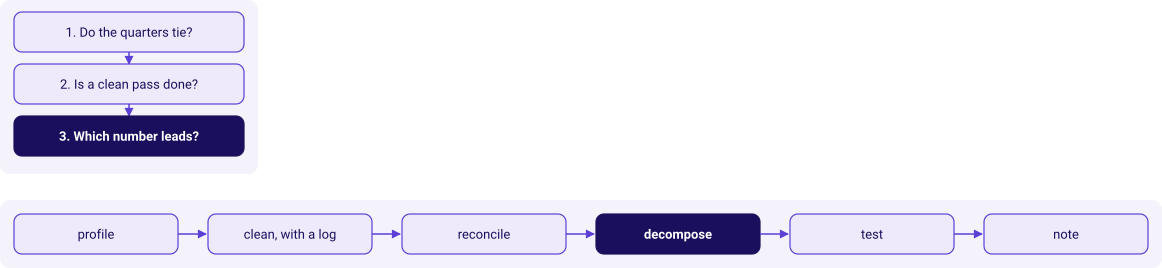

In [2]:
kit.side_by_side(
    kit.ladder(["Do the quarters tie?", "Is a clean pass done?", "Which number leads?"], lit=2, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=3, show=False),
)

## 1. Where in the tree does the fall sit?

**Predict before you run.** Which segment carries most of the invented export's Rs 14,00,000 fall?

- a) Retail-Core, the segment with the most orders.
- b) Retail-Plus, the members' tier.
- c) Business, the corporate book.
- d) Student, the smallest segment.

segment,orders Q1 / Q2,customers,orders per customer,revenue per order,revenue change,rupees moved
Retail-Core,36 / 36,24 / 24,1.50 / 1.50,"Rs 2,100 / Rs 2,080",-1.0%,-Rs 720
Retail-Plus,32 / 32,16 / 16,2.00 / 2.00,"Rs 3,000 / Rs 2,550",-15.0%,"-Rs 14,400"
Student,10 / 14,10 / 10,1.00 / 1.40,Rs 900 / Rs 880,+36.9%,"Rs 3,320"
Business,5 / 2,5 / 2,1.00 / 1.00,"Rs 7,63,880 / Rs 12,15,600",-36.3%,"-Rs 13,88,200"


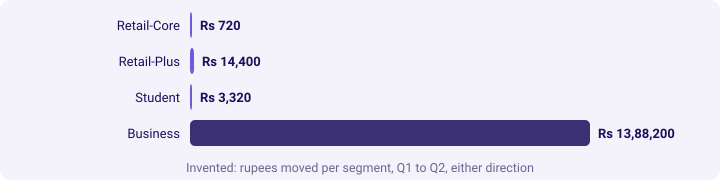

In [3]:
def tree(src, q, seg):
    rs = [r for r in src if r["quarter"] == q and r["segment"] == seg]
    cust = len({r["customer_id"] for r in rs})
    rev = sum(r["amount"] for r in rs)
    return {"orders": len(rs), "customers": cust, "freq": len(rs) / cust, "basket": rev / len(rs), "rev": rev}


def tree_table(src, caption):
    T = {(q, s): tree(src, q, s) for q in QUARTERS for s in SEGS}
    kit.table(["segment", "orders Q1 / Q2", "customers", "orders per customer", "revenue per order",
               "revenue change", "rupees moved"],
              [(s, f"{T['Q1', s]['orders']} / {T['Q2', s]['orders']}",
                f"{T['Q1', s]['customers']} / {T['Q2', s]['customers']}",
                f"{T['Q1', s]['freq']:.2f} / {T['Q2', s]['freq']:.2f}",
                f"{kit.rupees(T['Q1', s]['basket'])} / {kit.rupees(T['Q2', s]['basket'])}",
                f"{change(T['Q1', s]['rev'], T['Q2', s]['rev']):+.1f}%",
                kit.rupees(T['Q2', s]['rev'] - T['Q1', s]['rev'])) for s in SEGS], caption=caption)
    return T


T = tree_table(clean, "Invented: the clean tree, Q1 against Q2")
fall = ctl("Q1")[0] - ctl("Q2")[0]
biz = T["Q1", "Business"]["rev"] - T["Q2", "Business"]["rev"]
kit.stats([(f"{change(T['Q1', 'Business']['rev'], T['Q2', 'Business']['rev']):+.1f}%", "the corporate book",
            "revenue, Q1 to Q2, invented"),
           (kit.rupees(biz), "the fall it carries", f"{100 * biz / fall:.1f}% of the quarter's fall")])
kit.bars([(s, abs(T['Q2', s]['rev'] - T['Q1', s]['rev'])) for s in SEGS], lit=(3,), fmt=lambda v: kit.rupees(v),
         title="Invented: rupees moved per segment, Q1 to Q2, either direction")
kit.check("the segments add back to the quarter", all(sum(T[q, s]["rev"] for s in SEGS) == ctl(q)[0] for q in QUARTERS))

**What happened.** The answer is c. On the invented export Business carries Rs 13,88,200 of the Rs
14,00,000 fall, 99.2 percent of it, and its revenue fell 36.3 percent. Among consumers, Retail-Plus
kept its 16 members and their 2.00 orders each while its revenue per order fell 15.0 percent, from
Rs 3,000 to Rs 2,550.

**Your turn, on this morning's file.** Build the same tree on the lab export. Type these lines into
the empty cell below and run it; the later your-turn cells use `lab_clean`, so run this one first:

```python
lab, lab_book = load_export("lab")
lab_clean = tidy(lab)
LT = tree_table(lab_clean, "This morning's file: the clean tree, Q1 against Q2")
```

Which segment carries most of this morning's fall, and which consumer branch moved?

## 2. How many orders does the biggest move rest on?

**The plausible wrong answer.** "The corporate book fell 36.3 percent and drove the whole decline;
we recommend a corporate retention plan." It is true to the rupee and the biggest move on the page,
so a hurried note leads with it.

**Predict before you run.** The tree above puts five corporate orders in Q1 and two in Q2. If each
of the seven were equally likely to land in either quarter, how often would a split at least that
uneven come up?

- a) About 5 percent of the time.
- b) About 20 percent.
- c) About 45 percent.
- d) About 90 percent.

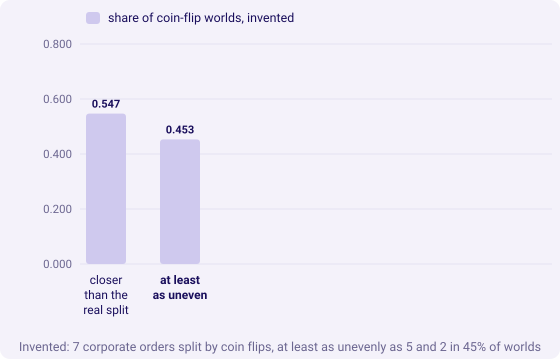

In [4]:
def coin_flip_share(n1, n2):
    """How often coin flips split n1 + n2 orders between two quarters at least as unevenly."""
    n, gap = n1 + n2, abs(n1 - n2)
    return sum(comb(n, k) for k in range(n + 1) if abs(2 * k - n) >= gap) / 2 ** n


b1, b2 = T["Q1", "Business"]["orders"], T["Q2", "Business"]["orders"]
uneven = coin_flip_share(b1, b2)
kit.columns(["closer than the real split", "at least as uneven"], [("share of coin-flip worlds, invented", [1 - uneven, uneven])],
            fmt=lambda v: f"{v:.3f}", lit=(1,), width=560,
            title=f"Invented: {b1 + b2} corporate orders split by coin flips, at least as unevenly as {b1} and {b2} in {uneven:.0%} of worlds")
kit.check("the corporate rate rests on fewer than thirty orders", b1 + b2 < 30, f"{b1} then {b2}")
kit.check("the corporate book carries more than nine tenths of the fall", biz / fall > 0.9)

**What happened.** The answer is c. If each of the seven orders were equally likely to land in
either quarter, a split at least as uneven as five and two would come up in 45 percent of worlds,
and a corporate order here is worth several lakh, so a change of two or three orders moves the book
by a third.

**Why it is wrong.** The rupees are real and Meera should hear them. What a handful of orders cannot
carry is the word "trend", or a plan built on it. The check is to count before you rate: put the
order count beside every rate before deciding which one leads, and ask how often chance alone moves
that many orders as unevenly.

**The fix, and what it changes.** The corporate fall goes into the note as counts, five orders then
two, beside the Rs 13,88,200 it carries, and its action is a question to whoever owns those
accounts, which costs a phone call. The lead moves to the branch that moved on enough orders to
read.

**Your turn, on this morning's file.** Count the lab file's corporate orders in each quarter and run
the same coin flips on them. Type these lines into the empty cell below and run it:

```python
lb1, lb2 = LT["Q1", "Business"]["orders"], LT["Q2", "Business"]["orders"]
print("corporate orders:", lb1, "in Q1 and", lb2, "in Q2;",
      f"coin flips split them at least that unevenly in {coin_flip_share(lb1, lb2):.1%} of worlds")
```

Then write the corporate line of your note as counts: the orders in each quarter, then the rupees.

## 3. How should a team choose the lead, and what does each way cost?

The cell below sizes four ways on the invented clean tree: the claim each leads with, the orders behind
that claim, how often chance alone produces it, and the analyst's minutes at the lab brief's pace.
Option D is run here, one test per segment on that segment's own customers' two quarters, so its
cost shows as a number.

| Option | How it picks the lead |
|---|---|
| A. The biggest rupee move | Whatever moved most in rupees leads |
| B. The total, unsplit | The quarter's change leads, and the split is left out |
| C. Count before rate | Every rate carries its order count; a rate on fewer than about thirty orders goes to the caveat as counts, and the lead is the branch that moved on enough orders and survives one test |
| D. Test everything | A test on every segment, and the smallest p-value leads |

option,leads with,orders behind it,chance alone,analyst minutes
A. biggest rupee move,Business -36.3%,7,45% of coin-flip worlds as uneven,5
"B. the total, unsplit",revenue -35.0%,167,not asked,2
C. count before rate,"Retail-Plus revenue per order -15.0%, Rs 14,400",64,"one test on its members' own two quarters, run at level 4",15
D. test every segment,the smallest of four p-values,7 to 72,"four tests, with a 0.19 chance that one looks real by luck; run at level 4",45


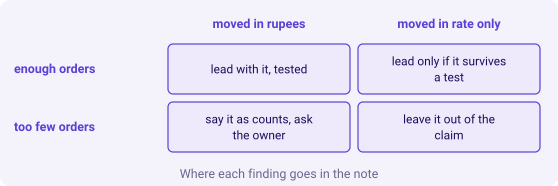

In [5]:
def members_of(src, seg):
    """Each customer of a segment with their own Q1 and Q2 orders, in customer order."""
    per = {}
    for r in src:
        if r["segment"] == seg:
            per.setdefault(r["customer_id"], {"Q1": [], "Q2": []})[r["quarter"]].append(r["amount"])
    return dict(sorted(per.items()))


def flipped_change(per, swaps, basket=True):
    """The segment's change from Q1 to Q2 with the swapped customers' two quarters exchanged."""
    q1r = q1n = q2r = q2n = 0
    for v, s in zip(per.values(), swaps):
        a, b = (v["Q2"], v["Q1"]) if s else (v["Q1"], v["Q2"])
        q1r, q1n, q2r, q2n = q1r + sum(a), q1n + len(a), q2r + sum(b), q2n + len(b)
    return change(q1r / q1n, q2r / q2n) if basket else change(q1r, q2r)


def paired_test(src, seg, basket=True, flips=2000, seed=7):
    """Flip each customer's own two quarters at random; the share of worlds as extreme, either way."""
    per = members_of(src, seg)
    observed = flipped_change(per, [False] * len(per), basket)
    rng = random.Random(seed)
    worlds = [flipped_change(per, [rng.random() < 0.5 for _ in per], basket) for _ in range(flips)]
    return observed, worlds, sum(1 for w in worlds if abs(w) >= abs(observed) - 1e-9) / flips


plus = [r for r in clean if r["segment"] == "Retail-Plus"]
obs_plus, worlds_plus, p_plus = paired_test(clean, "Retail-Plus")
four = [(s, *paired_test(clean, s, basket=False)[::2]) for s in SEGS]
false_alarm = 1 - 0.95 ** 4
kit.table(["option", "leads with", "orders behind it", "chance alone", "analyst minutes"], [
    ("A. biggest rupee move", f"Business {change(T['Q1', 'Business']['rev'], T['Q2', 'Business']['rev']):+.1f}%",
     b1 + b2, f"{uneven:.0%} of coin-flip worlds as uneven", 5),
    ("B. the total, unsplit", f"revenue {change(ctl('Q1')[0], ctl('Q2')[0]):+.1f}%", ctl("Q1")[1] + ctl("Q2")[1],
     "not asked", 2),
    ("C. count before rate", f"Retail-Plus revenue per order {obs_plus:+.1f}%, "
     f"{kit.rupees(T['Q1', 'Retail-Plus']['rev'] - T['Q2', 'Retail-Plus']['rev'])}", len(plus),
     "one test on its members' own two quarters, run at level 4", 15),
    ("D. test every segment", "the smallest of four p-values",
     f"{min(len([r for r in clean if r['segment'] == s]) for s in SEGS)} to "
     f"{max(len([r for r in clean if r['segment'] == s]) for s in SEGS)}",
     f"four tests, with a {false_alarm:.2f} chance that one looks real by luck; run at level 4", 45),
], caption="Invented: four ways to choose the lead, sized")
kit.matrix(["enough orders", "too few orders"], ["moved in rupees", "moved in rate only"],
           [["lead with it, tested", "lead only if it survives a test"],
            ["say it as counts, ask the owner", "leave it out of the claim"]],
           title="Where each finding goes in the note")

In [6]:
kit.check("Retail-Plus's basket rests on more than thirty orders", len(plus) > 30, f"{len(plus)} orders")
kit.check("two segments rest on thirty or more orders, and the other two on fewer",
          sorted(len([r for r in clean if r["segment"] == s]) >= 30 for s in SEGS) == [False, False, True, True])

**What happened, and the best-fit call.** C. It costs about fifteen minutes and one test, and on the
invented export it leads with Retail-Plus's revenue per order, down 15.0 percent on 64 orders, the
one consumer move on enough orders to test; level 4 runs that test. The move is small in rupees, Rs
14,400 of the fall, about 1 percent of it, so it leads among consumers while the corporate Rs
13,88,200 sits beside it in the claim as counts. A leads on seven orders, too few to call a trend. B
hides the one thing Meera most needs, that 99.2 percent of the fall is the corporate book. D spends
four tests at three times the minutes, and with four tests at 0.05 the chance that at least one
looks real by luck is about 19 percent, so on another file D leads with a fluke about one time in
five; level 4 runs it on this file.

**What would change the call.** A question about accounts: if Meera asked "what
happened to our corporate revenue?", the lead is the corporate fall, said as counts, with the
accounts named by their owner. A corporate book of hundreds of orders a quarter would let its rate
lead. And a second quarter of the same move in Business would turn a phone call into a trend worth
testing.

**Your turn, on this morning's file.** Run option D's four tests on the lab file and read which
segment each option would lead with there. Type these lines into the empty cell below and run it:

```python
for s in SEGS:
    o, _, p = paired_test(lab_clean, s, basket=False)
    print(f"{s}: revenue {o:+.1f}%, p = {p:.3f} with each customer's quarters flipped")
```

## 4. Is the lead's fall more than chance on its members' own two quarters?

Retail-Plus keeps its 16 members in both quarters, each placing the same number of orders in each
(one, two or three), while its revenue per order falls 15.0 percent. The claim is about the same
members in both quarters, so the fair test keeps each member's own two quarters together. In a world
where the quarter made no difference, each member's Q1 and Q2 are as likely either way round, so the
test swaps them at random for each member, recomputes the tier's revenue per order, and counts the
worlds with a change at least as large. The fall was found by reading the tree, so a rise of that
size counts as well, and the note reports both directions.

**Predict before you run.** Where does the real change sit among 2,000 worlds with each member's
quarters flipped at random?

- a) In the middle of the pile.
- b) At the edge: about two dozen worlds are as extreme.
- c) Beyond every flipped world.
- d) The test cannot run, since members placed different numbers of orders.

Invented: Retail-Plus revenue per order -15.0%; 22 of 2,000 flipped worlds as large either way, p = 0.0110; counted one way, 0.0015; exact over all 65,536 flip patterns, 0.0107


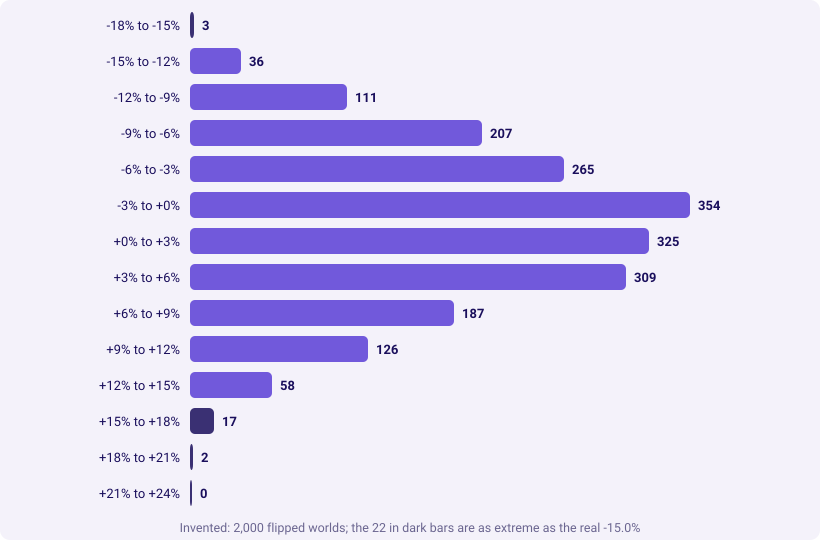

In [7]:
one_way = sum(1 for w in worlds_plus if w <= obs_plus + 1e-9) / 2000
per_plus = members_of(clean, "Retail-Plus")
diffs = [sum(v["Q2"]) - sum(v["Q1"]) for v in per_plus.values()]
total_rev = sum(sum(v["Q1"]) + sum(v["Q2"]) for v in per_plus.values())
dist = {0: 1}                       # every one of the 2^16 flip patterns, counted exactly
for d in diffs:
    nxt = {}
    for s, c in dist.items():
        nxt[s + d] = nxt.get(s + d, 0) + c
        nxt[s - d] = nxt.get(s - d, 0) + c
    dist = nxt
exact = sum(c for s, c in dist.items()
            if abs(change((total_rev - s) / 2, (total_rev + s) / 2)) >= abs(obs_plus) - 1e-9) / 2 ** len(diffs)
print(f"Invented: Retail-Plus revenue per order {obs_plus:+.1f}%; {round(p_plus * 2000)} of 2,000 flipped worlds as "
      f"large either way, p = {p_plus:.4f}; counted one way, {one_way:.4f}; exact over all "
      f"{2 ** len(diffs):,} flip patterns, {exact:.4f}")
edges = list(range(3 * (int(min(worlds_plus)) // 3 - 1), 3 * (int(max(worlds_plus)) // 3 + 2), 3))
extreme = [i for i, e in enumerate(edges) if e + 3 <= -abs(obs_plus) + 1e-9 or e >= abs(obs_plus) - 1e-9]
kit.bars([(f"{e:+d}% to {e + 3:+d}%", sum(1 for w in worlds_plus if e <= w < e + 3)) for e in edges], lit=extreme,
         width=820, title=f"Invented: 2,000 flipped worlds; the {round(p_plus * 2000)} in dark bars are as extreme "
                          f"as the real {obs_plus:+.1f}%")
kit.check("Retail-Plus's members and their frequency hold while its basket falls",
          T["Q1", "Retail-Plus"]["customers"] == T["Q2", "Retail-Plus"]["customers"]
          and abs(T["Q1", "Retail-Plus"]["freq"] - T["Q2", "Retail-Plus"]["freq"]) < 0.01)
kit.check("the sampled share and the exact share agree within the wobble of 2,000 flips", abs(p_plus - exact) < 0.005,
          f"{p_plus:.4f} against {exact:.4f}")
kit.check("the dark bars hold exactly the worlds counted as extreme",
          sum(sum(1 for w in worlds_plus if edges[i] <= w < edges[i] + 3) for i in extreme) == round(p_plus * 2000))

**What happened.** The answer is b. Only 22 of 2,000 flipped worlds show a change as large as the
invented Retail-Plus's, in either direction: p = 0.011, a share of chance-only worlds, never the
chance the finding is wrong. Counting every one of the 65,536 ways to flip sixteen members gives
0.0107, so 2,000 flips land close. Counted one way, a fall at least as large, it is 0.0015, the
number a note would quote only if the fall had been predicted before the data was seen; it was found
in the tree, so the note reports both directions.

**Option D, run.** One test per segment, each on its own customers' two quarters, now that the
lead's own test is in: the cell below shows whether any second segment comes in under 0.05.

In [8]:
kit.table(["segment", "revenue change", "p, each customer's quarters flipped, 2,000 times"],
          [(s, f"{o:+.1f}%", f"{p:.3f}") for s, o, p in four], caption="Invented: option D, run, one test per segment")
kit.check("Retail-Plus's fall is one chance rarely produces on its members' own quarters", p_plus < 0.05,
          f"p = {p_plus:.3f}")
kit.check("testing every segment turns up no second finding under 0.05", sum(1 for f in four if f[2] < 0.05) == 1)

segment,revenue change,"p, each customer's quarters flipped, 2,000 times"
Retail-Core,-1.0%,0.828
Retail-Plus,-15.0%,0.011
Student,+36.9%,0.060
Business,-36.3%,0.370


**What happened.** Only Retail-Plus comes in under 0.05, so D finds the same lead as C, at three
times the minutes and with four chances of a fluke where C took one.

**A different question needs a different test.** "Did Retail-Plus's basket move differently from
Retail-Core's?" compares two groups of different customers. There the fair test shuffles the segment
label across whole customers, each carrying all their orders with them, and asks how often a gap as
large as the real one turns up.

In [9]:
def basket_change(rs):
    a = [r["amount"] for r in rs if r["quarter"] == "Q1"]
    b = [r["amount"] for r in rs if r["quarter"] == "Q2"]
    return change(sum(a) / len(a), sum(b) / len(b))


def between_test(src, seg_a, seg_b, shuffles=2000, seed=7):
    """The gap in basket change between two segments, and the share of label shuffles across whole customers as large."""
    a_rows = [r for r in src if r["segment"] == seg_a]
    b_rows = [r for r in src if r["segment"] == seg_b]
    gap = basket_change(a_rows) - basket_change(b_rows)
    groups = {}
    for r in a_rows + b_rows:
        groups.setdefault(r["customer_id"], []).append(r)
    ids, n_a = sorted(groups), len({r["customer_id"] for r in a_rows})
    rng = random.Random(seed)
    hits = 0
    for _ in range(shuffles):
        m = ids[:]
        rng.shuffle(m)
        hits += abs(basket_change([r for c in m[:n_a] for r in groups[c]])
                    - basket_change([r for c in m[n_a:] for r in groups[c]])) >= abs(gap)
    return gap, hits / shuffles


gap_core, p_between = between_test(clean, "Retail-Plus", "Retail-Core")
kit.table(["the question", "the fair test", "p, both directions"], [
    ("did Retail-Plus's revenue per order fall?", "each member's two quarters flipped", f"{p_plus:.4f}"),
    ("did it move differently from Retail-Core's?", "segment label shuffled across whole customers", f"{p_between:.4f}")],
    caption=f"Invented: two questions about one finding; the gap to Retail-Core is {gap_core:+.1f} points")
kit.check("both fair tests put the finding outside what chance usually does", p_plus < 0.05 and p_between < 0.05)

the question,the fair test,"p, both directions"
did Retail-Plus's revenue per order fall?,each member's two quarters flipped,0.0110
did it move differently from Retail-Core's?,segment label shuffled across whole customers,0.0385


**What happened.** Both fair tests put the invented finding outside what chance usually does: 0.011
for the fall itself, and 0.0385 for a gap of 14.0 points to Retail-Core, a different question with
its own fair test.

**The note, with the right lead, on the invented export.** Claim: booked revenue fell 35.0 percent,
from Rs 40,00,000 to Rs 26,00,000; Rs 13,88,200 of it is the corporate book, and among consumers
the branch that moved is Retail-Plus's revenue per order, down 15.0 percent from Rs 3,000 to Rs
2,550 with its 16 members and their frequency unchanged. Evidence: both quarters reconcile to
Finance's control totals; with each member's two quarters flipped at random, a change this large in
either direction came up in 22 of 2,000 worlds, p = 0.011. Caveat: the corporate move rests on five
orders then two, too few to call a trend. Action: ask the corporate account owner why fewer
corporate orders came in, and open Retail-Plus's basket (items per order and price per item) before
any spend.

**Your turn, on this morning's file.** Test the consumer branch your lab tree says moved on enough
orders, on its own customers' two quarters, and then against another segment. Put that segment's
name in `LEAD` and the one you compare it with in `OTHER`, then type these lines into the empty
cell below and run it:

```python
LEAD, OTHER = "...", "..."
lab_obs, lab_worlds, lab_p = paired_test(lab_clean, LEAD)
print(f"{LEAD} revenue per order {lab_obs:+.1f}%, p = {lab_p:.4f} both ways")
print("gap to", OTHER, "and its p across whole customers:", between_test(lab_clean, LEAD, OTHER))
```

## 5. Is the fall broad, or carried by a few members?

The flips compare the tier's average. A second route reads each member on their own: of Retail-Plus's
members, how many saw their own average order fall? If the fall is real and broad, most of them
should, and a sign test says how often coin flips alone would split the members at least that
unevenly.

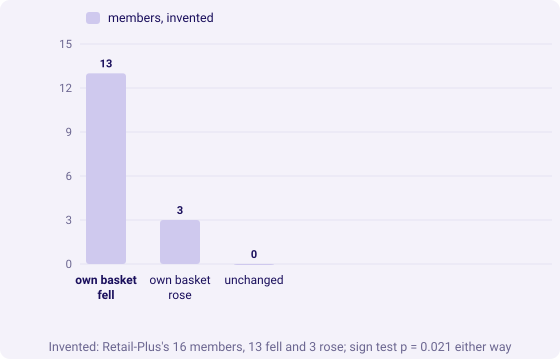

In [10]:
def sign_test(src, seg):
    per = members_of(src, seg)
    fell = sum(1 for v in per.values() if sum(v["Q2"]) / len(v["Q2"]) < sum(v["Q1"]) / len(v["Q1"]))
    rose = sum(1 for v in per.values() if sum(v["Q2"]) / len(v["Q2"]) > sum(v["Q1"]) / len(v["Q1"]))
    moved = fell + rose
    return fell, rose, len(per) - moved, 2 * sum(comb(moved, k) for k in range(min(fell, rose) + 1)) / 2 ** moved


fell, rose, same, sign_p = sign_test(clean, "Retail-Plus")
kit.columns(["own basket fell", "own basket rose", "unchanged"], [("members, invented", [fell, rose, same])],
            lit=(0,), width=560,
            title=f"Invented: Retail-Plus's {fell + rose + same} members, {fell} fell and {rose} rose; sign test p = {sign_p:.3f} either way")
kit.check("most members saw their own basket fall", fell > (fell + rose + same) / 2, f"{fell} of {fell + rose + same}")
kit.check("the sign test puts the split outside what coin flips usually do", sign_p < 0.05, f"p = {sign_p:.3f}")
kit.check("the second route points the same way as the flips", (fell > rose) == (obs_plus < 0))

**What happened.** Of the invented Retail-Plus's 16 members, 13 saw their own average order fall
and 3 saw it rise. Coin flips split sixteen members at least that unevenly in 2.1 percent of
worlds, either way, so the sign test agrees with the flips.

**When to switch routes.** The flips say whether the tier's change is bigger than chance; the
member count says whether it is broad or carried by a few people. When the two disagree, a handful
of members moved the average, and the note says so. The sign test uses only the direction of each
member's change, which is why its p of 0.021 sits above the flips' 0.011.

**Your turn, on this morning's file.** Run the sign test on your lab lead. Type this line into the
empty cell below and run it:

```python
print(LEAD, "fell, rose, unchanged and the sign test's p:", sign_test(lab_clean, LEAD))
```

> **Kavya's review.** Say the count before the rate, every time: the orders in each quarter, then
> the percentage. "Down 36 percent" alone is a headline, and Marketing will take it apart with one
> question.

### How would you answer this in an interview?

**[S] Tell me about an analysis you did: what did you find, and how sure are you?** "On a
two-quarter export in training, revenue fell 35.0 percent after I reconciled it to Finance's control
totals. Almost all of it was the corporate book, on seven orders, which I reported as counts and
passed to the account owner. The finding I led with was one tier's revenue per order, down 15.0
percent on 64 orders with its members and their frequency flat. The same 16 members were in both
quarters, so I tested it by flipping each member's two quarters at random: p = 0.011 counting either
direction, and 13 of the 16 saw their own basket fall. My caveat was the corporate book's count."

**[D] A stakeholder attacks your caveat in front of the room; how do you hold it without
overclaiming?** "I restate the claim with its count, bound what the data can say, and offer the test
that would settle it with its size and time. For the corporate book: seven orders cannot tell a trend
from an account or two pausing; a call to the account owner settles which it is by Monday."

**The design question: four segments moved; which do you test?** "One: the branch the tree says
moved on enough orders to read, tested on its own customers' two quarters. Testing all four at 0.05
gives about a one-in-five chance that something looks real by luck, and a test on a handful of
orders cannot say anything a count does not."

## Depth: what happens when a test splits a member's two quarters?

Two tests a hurried analyst reaches for split what belongs together. Pooling the members' Q1 and Q2
figures and dealing the quarter labels at random treats a member's own two quarters as two
strangers; shuffling segment labels across single orders splits one customer's orders between the
groups. Either can move p in either direction. On the invented export both come out larger than the
fair test's, because members differ in size far more than each member's own quarters differ from
each other, and a test that splits the pair throws that pairing away. Where a question compares
groups and a customer's orders are alike, splitting them more often makes p too small, because
correlated orders count as extra evidence. The cell below runs each fair test beside its hurried
twin, on the same measure.

In [11]:
def split_tests(src, seg, other, seed=7):
    """Each fair test beside the hurried twin that splits the pair, on one segment and one comparison."""
    per = members_of(src, seg)
    r1 = [sum(v["Q1"]) for v in per.values()]
    r2 = [sum(v["Q2"]) for v in per.values()]
    real = sum(r1) / len(r1) - sum(r2) / len(r2)
    rng = random.Random(seed)
    pool, dealt = r1 + r2, []
    for _ in range(2000):
        rng.shuffle(pool)
        dealt.append(sum(pool[:len(r1)]) / len(r1) - sum(pool[len(r1):]) / len(r2))
    p_pooled = sum(1 for g in dealt if abs(g) >= abs(real) - 1e-9) / 2000
    d = [b - a for a, b in zip(r1, r2)]
    rng = random.Random(seed)
    p_flip = sum(1 for _ in range(2000) if abs(sum(x if rng.random() < 0.5 else -x for x in d)) >= abs(sum(d)) - 1e-9) / 2000
    a_rows = [r for r in src if r["segment"] == seg]
    b_rows = [r for r in src if r["segment"] == other]
    gap, p_whole = between_test(src, seg, other)
    both_rows = a_rows + b_rows
    rng = random.Random(seed)
    ext = 0
    for _ in range(2000):
        idx = list(range(len(both_rows)))
        rng.shuffle(idx)
        ext += abs(basket_change([both_rows[i] for i in idx[:len(a_rows)]])
                   - basket_change([both_rows[i] for i in idx[len(a_rows):]])) >= abs(gap)
    return [("revenue per customer, Q1 to Q2", "each customer's two quarters flipped", "each customer's own pair", f"{p_flip:.4f}"),
            ("revenue per customer, Q1 to Q2", "Q1 and Q2 figures pooled and dealt", "nothing", f"{p_pooled:.4f}"),
            (f"revenue per order, gap to {other}", "segment label across whole customers", "each customer's orders", f"{p_whole:.4f}"),
            (f"revenue per order, gap to {other}", "segment label across single orders", "nothing", f"{ext / 2000:.4f}")]


depth = split_tests(clean, "Retail-Plus", "Retail-Core")
kit.table(["measure", "the test", "what it keeps together", "p, both directions"], depth,
          caption="Invented: each fair test beside the hurried twin that splits the pair")
kit.check("splitting the pairs pushes both verdicts past 0.05 on the invented export",
          float(depth[1][3]) > 0.05 > float(depth[0][3]) and float(depth[3][3]) > 0.05 > float(depth[2][3]))

measure,the test,what it keeps together,"p, both directions"
"revenue per customer, Q1 to Q2",each customer's two quarters flipped,each customer's own pair,0.0025
"revenue per customer, Q1 to Q2",Q1 and Q2 figures pooled and dealt,nothing,0.2220
"revenue per order, gap to Retail-Core",segment label across whole customers,each customer's orders,0.0385
"revenue per order, gap to Retail-Core",segment label across single orders,nothing,0.0945


**What happened.** On the invented export, flipping each member's two quarters puts the fall in
revenue per member at p = 0.0025, and pooling the same figures and dealing them reads it as chance,
p = 0.222; shuffling the label across whole customers puts the gap to Retail-Core at 0.0385, and
shuffling single orders reads it as chance too, 0.0945, so the test that splits the pair reached the
wrong verdict both times on the same data.

**Your turn, on this morning's file.** Run the same four tests on your lab lead and the segment you
compared it with. Type this line into the empty cell below and run it:

```python
kit.table(["measure", "the test", "what it keeps together", "p, both directions"], split_tests(lab_clean, LEAD, OTHER),
          caption="This morning's file: each fair test beside its hurried twin")
```

Which way did the hurried twins move p on this morning's file, and would either have changed the
verdict?

### Which number describes a typical order in this file?

A note that says "the typical order" needs one number, and a file with a few corporate orders among
the consumer ones pulls its mean far from what most customers spend.

In [12]:
amounts = sorted(r["amount"] for r in clean)
typical = [("mean order, clean", round(statistics.mean(amounts))), ("median order, clean", statistics.median(amounts))]
kit.table(["measure", "value"], [(m, kit.rupees(v)) for m, v in typical], caption="Invented: the typical order")
kit.check("the mean sits more than ten times above the median", typical[0][1] > 10 * typical[1][1],
          f"{kit.rupees(typical[0][1])} against {kit.rupees(typical[1][1])}")

measure,value
"mean order, clean","Rs 39,521"
"median order, clean","Rs 2,350"


**What happened.** The mean order, Rs 39,521, is pulled up by seven corporate orders and describes no
order anybody placed; the median, Rs 2,350, is the typical one, and the mean belongs in anything that
must reconcile.

## So, which finding leads the note, and how sure can Meera be of it?

The branch that moved on enough orders to test leads, said beside the biggest move as counts. On
the invented export:

1. Business carries Rs 13,88,200 of the Rs 14,00,000 fall, 99.2 percent, with its revenue down 36.3
   percent.
2. That rate rests on five orders then two, and coin flips split seven orders at least that unevenly
   in 45 percent of worlds.
3. Count before rate (C) is the best fit: Retail-Plus's revenue per order, down 15.0 percent on 64
   orders, leads among consumers, and D finds the same lead at three times the minutes with a 19
   percent chance of a fluke.
4. With each member's two quarters flipped, 22 of 2,000 worlds are as extreme either way, p = 0.011
   (0.0107 counted exactly).
5. 13 of the 16 members saw their own basket fall, a sign test p of 0.021, so the fall is broad.

Meera can act on it as a finding worth opening, sized at Rs 14,400 a quarter, with the corporate
book beside it as a question to its account owner. The your-turn cells put this morning's file
through the same five questions, and the note's four parts and the p-value sentence are both on
Saturday's paper.

In [13]:
kit.check_summary()
print("Next: the rehearsal, where the note is said aloud and Marketing pushes on it.")

Next: the rehearsal, where the note is said aloud and Marketing pushes on it.
